# US Census Demographic Data
### Predykcja dochodu na osobę w zależności od danych demograficznych i ekonomicznych w Stanach Zjednoczonych

#### Analiza eksploracyjna danych

Celem analizy eksploracyjnej danych jest sprawdzenie zależności między posiadanymi danymi  
(2,5 pkt.), zbadanie ich zakresów i stopnia zmienności (2,5 pkt.), analiza stopnia wypełnienia 
danych (2,5 pkt.), wizualizacja (2,5 pkt.). Wynikiem tych analiz, ma być raport zakończony 
postawieniem hipotezy badawczej mającej na celu znalezienie relacji między zmiennymi 
objaśniającymi, a zmienną objaśnianą. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie zbioru i określenie liczby hrabstw

In [2]:
df = pd.read_csv("data/acs2017_county_data.csv")

display(df.head())

num_counties = df.shape[0]
print("Liczba hrabstw:",num_counties)

num_attr = df.shape[1]
print("Liczba atrybutów:", num_attr)

print("Nazwy atrybutów:")
print(df.columns.values)

df.drop_duplicates()

num_counties_aft_drop = df.shape[0]
if num_counties != num_counties_aft_drop:
    print("Występują powtórzenia w zbiorze i jest ich:", num_counties - num_counties_aft_drop)

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,0.6,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,0.8,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,2.2,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,0.3,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9


Liczba hrabstw: 3220
Liczba atrybutów: 37
Nazwy atrybutów:
['CountyId' 'State' 'County' 'TotalPop' 'Men' 'Women' 'Hispanic' 'White'
 'Black' 'Native' 'Asian' 'Pacific' 'VotingAgeCitizen' 'Income'
 'IncomeErr' 'IncomePerCap' 'IncomePerCapErr' 'Poverty' 'ChildPoverty'
 'Professional' 'Service' 'Office' 'Construction' 'Production' 'Drive'
 'Carpool' 'Transit' 'Walk' 'OtherTransp' 'WorkAtHome' 'MeanCommute'
 'Employed' 'PrivateWork' 'PublicWork' 'SelfEmployed' 'FamilyWork'
 'Unemployment']


In [3]:
df.describe()

,CountyId,TotalPop,Men,Women,Hispanic,White,Black,Native,Asian,Pacific,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
count,3220.000000,3.220000e+03,3.220000e+03,3.220000e+03,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000,...,3220.000000,3220.000000,3220.000000,3220.000000,3.220000e+03,3220.000000,3220.000000,3220.000000,3220.000000,3220.000000
mean,31393.605280,1.007681e+05,4.958781e+04,5.118032e+04,11.296584,74.920186,8.681957,1.768416,1.289379,0.083416,...,3.244472,1.598696,4.736894,23.474534,4.709295e+04,74.863323,17.086118,7.772733,0.278820,6.665590
std,16292.078954,3.244996e+05,1.593212e+05,1.652164e+05,19.342522,23.056700,14.333571,7.422946,2.716191,0.709277,...,3.891510,1.678232,3.073484,5.687241,1.558159e+05,7.647916,6.390868,3.855454,0.448073,3.772612
min,1001.000000,7.400000e+01,3.900000e+01,3.500000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.100000,3.900000e+01,31.100000,4.400000,0.000000,0.000000,0.000000
25%,19032.500000,1.121350e+04,5.645500e+03,5.553500e+03,2.100000,63.500000,0.600000,0.100000,0.200000,0.000000,...,1.400000,0.800000,2.900000,19.600000,4.573000e+03,71.200000,12.700000,5.200000,0.100000,4.475000
50%,30024.000000,2.584750e+04,1.287900e+04,1.299350e+04,4.100000,83.600000,2.000000,0.300000,0.600000,0.000000,...,2.300000,1.300000,4.100000,23.200000,1.061150e+04,76.100000,15.900000,6.800000,0.200000,6.100000
75%,46105.500000,6.660825e+04,3.301725e+04,3.359375e+04,10.000000,92.800000,9.500000,0.600000,1.200000,0.100000,...,3.825000,1.900000,5.800000,27.000000,2.874725e+04,80.200000,19.900000,9.200000,0.300000,8.000000
max,72153.000000,1.010572e+07,4.979641e+06,5.126081e+06,100.000000,100.000000,86.900000,90.300000,41.800000,33.700000,...,59.200000,43.200000,33.000000,45.100000,4.805817e+06,88.800000,64.800000,38.000000,8.000000,40.900000


Analiza braków danych

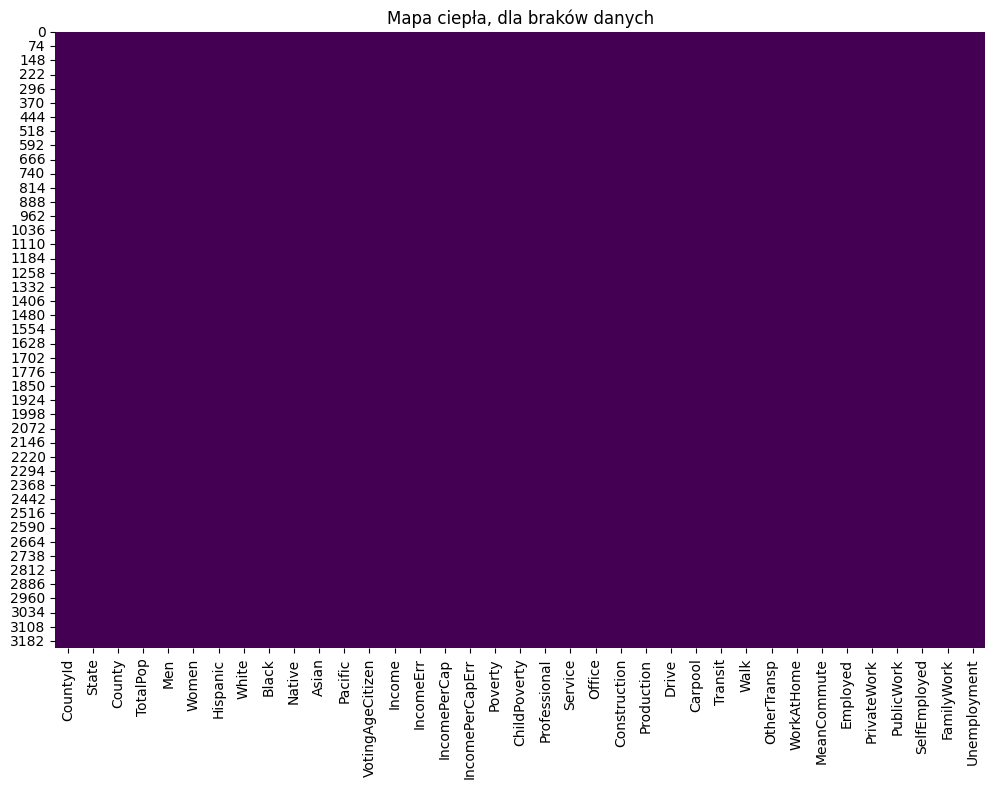


Braki w danych liczone wg. atrybutów
ChildPoverty    1
dtype: int64

Braki w danych liczone wg. obiektów

Braki w danych liczone wg. obiektów
548    1
dtype: int64


(ChildPoverty    1
 dtype: int64,
 548    1
 dtype: int64)

In [4]:
from missing_values import analyze

analyze(df)

In [5]:
print("Hrabstwo, dla którego występuje brak:", df.loc[548, "County"])
print("Jego liczba mieszkańców:", df.loc[548, "TotalPop"])

Hrabstwo, dla którego występuje brak: Kalawao County
Jego liczba mieszkańców: 86


Hrabstwo to ma 86 mieszkańców i znajduje się w stanie Hawaii (jest to wyspa), więc myślę, że można je pominąć w analizie

Kolumna, dla której występował brak

In [6]:
df["ChildPoverty"]

0       20.1
1       16.1
2       44.9
3       26.6
4       25.4
        ... 
3215    49.4
3216    68.2
3217    67.9
3218    62.1
3219    58.2
Name: ChildPoverty, Length: 3220, dtype: float64

In [7]:
df = df.dropna()
print("Ilość obiektów po usunięcie braków:", df.shape[0])

Ilość obiektów po usunięcie braków: 3219


In [8]:
# indeksy atrybutów, które chcemy wczytać
col_idx = list(range(213, 225))
col_idx.insert(0, 2)
col_idx.insert(1, 4)
df_m = pd.read_csv("data/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv", usecols = col_idx)

df_m.head()

,RegionName,StateName,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
0,Los Angeles County,CA,496432.165871,507859.677641,520913.658719,530631.397967,537244.275959,542477.432796,542385.620441,540013.644416,536369.348970,536864.968049,538689.381948,541662.049466
1,Cook County,IL,213212.551902,214911.562420,216700.376163,217918.756026,218702.731358,218548.139244,218452.791111,218348.257780,219114.410602,220283.185939,221663.939129,223089.429643
2,Harris County,TX,178867.362531,179293.936080,179865.512649,180606.507008,181295.097794,181900.420107,182275.200113,182736.328973,183150.923275,183801.630746,184547.835710,185331.960500
3,Maricopa County,AZ,246051.872009,247371.898175,248821.126990,250356.606120,251795.821571,253212.799829,254578.486102,256004.502478,257477.687867,259015.835934,260282.302938,261556.469755
4,San Diego County,CA,527134.172852,531398.707245,534337.134033,537429.740566,540009.645298,543344.843806,545744.662180,549008.592430,552204.949203,556710.483291,560643.580571,565084.374180


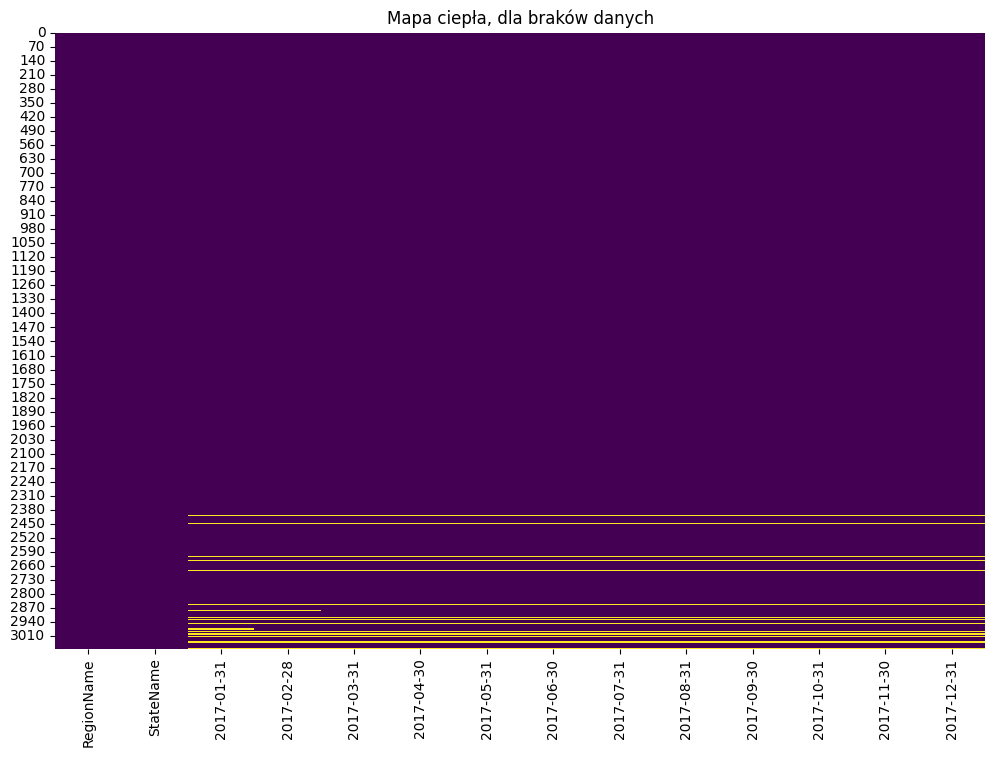


Braki w danych liczone wg. atrybutów
2017-01-31    101
2017-02-28     95
2017-03-31     94
2017-04-30     94
2017-05-31     94
2017-06-30     94
2017-07-31     94
2017-08-31     94
2017-09-30     94
2017-10-31     94
2017-11-30     94
2017-12-31     94
dtype: int64

Braki w danych liczone wg. obiektów

Braki w danych liczone wg. obiektów
1062    12
1734    12
1857    12
2062    12
2161     1
        ..
3068    12
3069    12
3070    12
3071    12
3072    12
Length: 101, dtype: int64


In [9]:
from missing_values import analyze

missing_attributes, missing_objects = analyze(df_m)

In [10]:
print(missing_attributes)
print(missing_objects)

2017-01-31    101
2017-02-28     95
2017-03-31     94
2017-04-30     94
2017-05-31     94
2017-06-30     94
2017-07-31     94
2017-08-31     94
2017-09-30     94
2017-10-31     94
2017-11-30     94
2017-12-31     94
dtype: int64
1062    12
1734    12
1857    12
2062    12
2161     1
        ..
3068    12
3069    12
3070    12
3071    12
3072    12
Length: 101, dtype: int64


In [11]:
missing_objects_filtred = missing_objects[missing_objects > 6]
missing_objects_filtred
type(missing_objects.index.values)
df_m.loc[missing_objects_filtred.index.values, :]

,RegionName,StateName,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
1062,Washington County,MS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1734,Wyoming County,WV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1857,McDowell County,WV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2062,Lawrence County,IL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2172,McKenzie County,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3068,Loup County,NE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3069,Banner County,NE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3070,Daggett County,UT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3071,Thomas County,NE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ponieważ hrabstw, dla których nie mamy co najmiej połowy średniej ceny domów w ciągu roku, nie jest tak dużo, dokładnie 94, nie będziemy dalej uwzględniać tych danych, gdyż jest to ok 3% danych z całego zbioru.

In [12]:
df_m_cleaned = df_m.dropna(subset=df_m.columns[1:], how='all')

df_m_cleaned = df_m_cleaned.assign(Average_House_Price=df_m_cleaned.iloc[:, 2:].mean(axis=1))
df_m_cleaned.drop(df_m_cleaned.columns[2:14], axis = 1, inplace = True)
df_m_cleaned = df_m_cleaned.rename(columns={"RegionName": "County",})
df_m_cleaned

,County,StateName,Average_House_Price
0,Los Angeles County,CA,530961.968520
1,Cook County,IL,218412.177610
2,Harris County,TX,181972.726290
3,Maricopa County,AZ,253877.117481
4,San Diego County,CA,545254.240471
...,...,...,...
3069,Banner County,NE,NaN
3070,Daggett County,UT,NaN
3071,Thomas County,NE,NaN
3072,McPherson County,NE,NaN


Trzeba dodać kolumnę State, bo same nazwy Hrabstw się powtarzają

In [13]:
# słownik skrótów na pełne nazwy stanów
state_abbrev_to_name = {
    'AL': 'Alabama',
    'AK': 'Alaska',
    'AZ': 'Arizona',
    'AR': 'Arkansas',
    'CA': 'California',
    'CO': 'Colorado',
    'CT': 'Connecticut',
    'DE': 'Delaware',
    'DC': 'District of Columbia',
    'FL': 'Florida',
    'GA': 'Georgia',
    'HI': 'Hawaii',
    'ID': 'Idaho',
    'IL': 'Illinois',
    'IN': 'Indiana',
    'IA': 'Iowa',
    'KS': 'Kansas',
    'KY': 'Kentucky',
    'LA': 'Louisiana',
    'ME': 'Maine',
    'MD': 'Maryland',
    'MA': 'Massachusetts',
    'MI': 'Michigan',
    'MN': 'Minnesota',
    'MS': 'Mississippi',
    'MO': 'Missouri',
    'MT': 'Montana',
    'NE': 'Nebraska',
    'NV': 'Nevada',
    'NH': 'New Hampshire',
    'NJ': 'New Jersey',
    'NM': 'New Mexico',
    'NY': 'New York',
    'NC': 'North Carolina',
    'ND': 'North Dakota',
    'OH': 'Ohio',
    'OK': 'Oklahoma',
    'OR': 'Oregon',
    'PA': 'Pennsylvania',
    'RI': 'Rhode Island',
    'SC': 'South Carolina',
    'SD': 'South Dakota',
    'TN': 'Tennessee',
    'TX': 'Texas',
    'UT': 'Utah',
    'VT': 'Vermont',
    'VA': 'Virginia',
    'WA': 'Washington',
    'WV': 'West Virginia',
    'WI': 'Wisconsin',
    'WY': 'Wyoming',
    'PR': 'Puerto Rico'
}

print(len(state_abbrev_to_name))

df_m_cleaned = df_m_cleaned.assign(State=df_m_cleaned.iloc[:, 1].map(state_abbrev_to_name))
df_m_cleaned.drop(columns="StateName", axis = 1, inplace = True)
df_m_cleaned.dropna(inplace = True)

52


In [14]:
df_merged = df.merge(df_m_cleaned, on = ["County", "State"])
df_merged

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,Average_House_Price
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2,165762.733670
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5,220506.516160
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4,102728.580656
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2,136090.576591
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9,149837.831351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2889,56037,Wyoming,Sweetwater County,44527,22981,21546,16.0,79.6,0.8,0.6,...,1.3,1.5,20.5,22739,78.4,17.8,3.8,0.0,5.2,215516.381769
2890,56039,Wyoming,Teton County,22923,12169,10754,15.0,81.5,0.5,0.3,...,3.8,5.7,14.3,14492,82.1,11.4,6.5,0.0,1.3,977443.497682
2891,56041,Wyoming,Uinta County,20758,10593,10165,9.1,87.7,0.1,0.9,...,1.3,2.0,19.9,9528,71.5,21.5,6.6,0.4,6.4,186634.689280
2892,56043,Wyoming,Washakie County,8253,4118,4135,14.2,82.2,0.3,0.4,...,1.3,4.4,14.3,3833,69.8,22.0,8.1,0.2,6.1,167179.509742


Po połączeniu zbiorów pozostało 2894 rekordów, czyli utraciliśmy 370 rekordów, czyli trochę ponad 10% danych. Problematyczne jest tu określony jako stan Peurto Rico, do którego nie udało się połączyć ceny nieruchomości, z braków danych

Sprawdzenie wypełnienia dla lat 2015:
 - Usunięte względem poprzedniego commita
 - W zbiorze danych z Zillow po prostu było za dużo braków dla 2015 (ponad 500), gdzie dla 2017 jest ich mniej (około 100)

In [15]:
df_merged.head()

,CountyId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,Average_House_Price
0,1001,Alabama,Autauga County,55036,26899,28137,2.7,75.4,18.9,0.3,...,1.3,2.5,25.8,24112,74.1,20.2,5.6,0.1,5.2,165762.733670
1,1003,Alabama,Baldwin County,203360,99527,103833,4.4,83.1,9.5,0.8,...,1.1,5.6,27.0,89527,80.7,12.9,6.3,0.1,5.5,220506.516160
2,1005,Alabama,Barbour County,26201,13976,12225,4.2,45.7,47.8,0.2,...,1.7,1.3,23.4,8878,74.1,19.1,6.5,0.3,12.4,102728.580656
3,1007,Alabama,Bibb County,22580,12251,10329,2.4,74.6,22.0,0.4,...,1.7,1.5,30.0,8171,76.0,17.4,6.3,0.3,8.2,136090.576591
4,1009,Alabama,Blount County,57667,28490,29177,9.0,87.4,1.5,0.3,...,0.4,2.1,35.0,21380,83.9,11.9,4.0,0.1,4.9,149837.831351


#### Wartości odstające

In [16]:
print(df_merged.columns.tolist())

['CountyId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment', 'Average_House_Price']


In [17]:
numerical_cols = df_merged.select_dtypes(include=['number']).columns.tolist()
print("Zmienne numeryczne: ", numerical_cols)

Zmienne numeryczne:  ['CountyId', 'TotalPop', 'Men', 'Women', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen', 'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty', 'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction', 'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Unemployment', 'Average_House_Price']


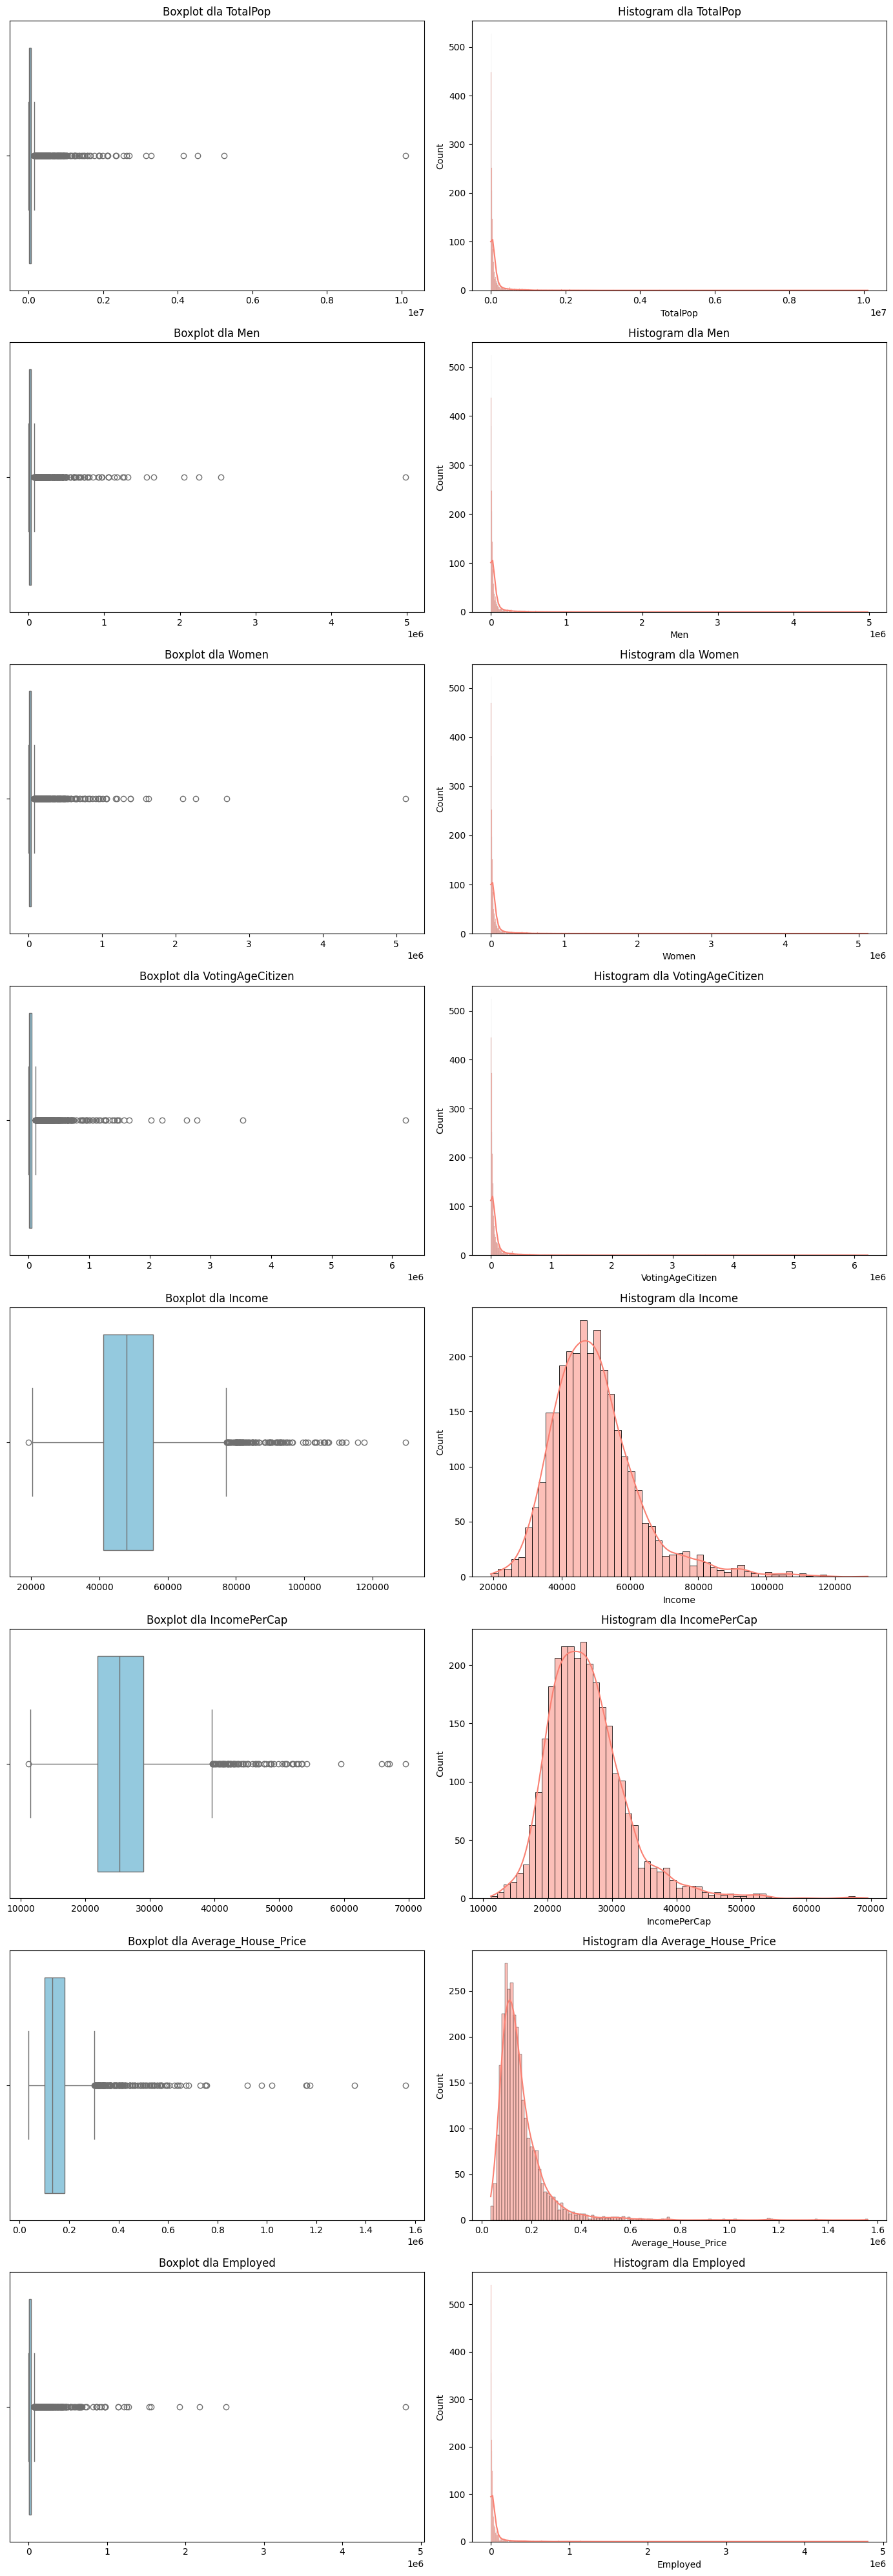

In [41]:
non_percentage_columns = [
    "TotalPop", "Men", "Women", "VotingAgeCitizen", "Income", "IncomePerCap", "Average_House_Price", "Employed"
]

fig, axes = plt.subplots(len(non_percentage_columns), 2, figsize=(14, len(non_percentage_columns) * 5))

for i, column in enumerate(non_percentage_columns):
    sns.boxplot(data=df_merged, x=column, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"Boxplot dla {column}")
    axes[i, 0].set_xlabel("")
    
    sns.histplot(data=df_merged, x=column, kde=True, ax=axes[i, 1], color="salmon")
    axes[i, 1].set_title(f"Histogram dla {column}")
    axes[i, 1].set_xlabel(column)

plt.tight_layout()
plt.show()


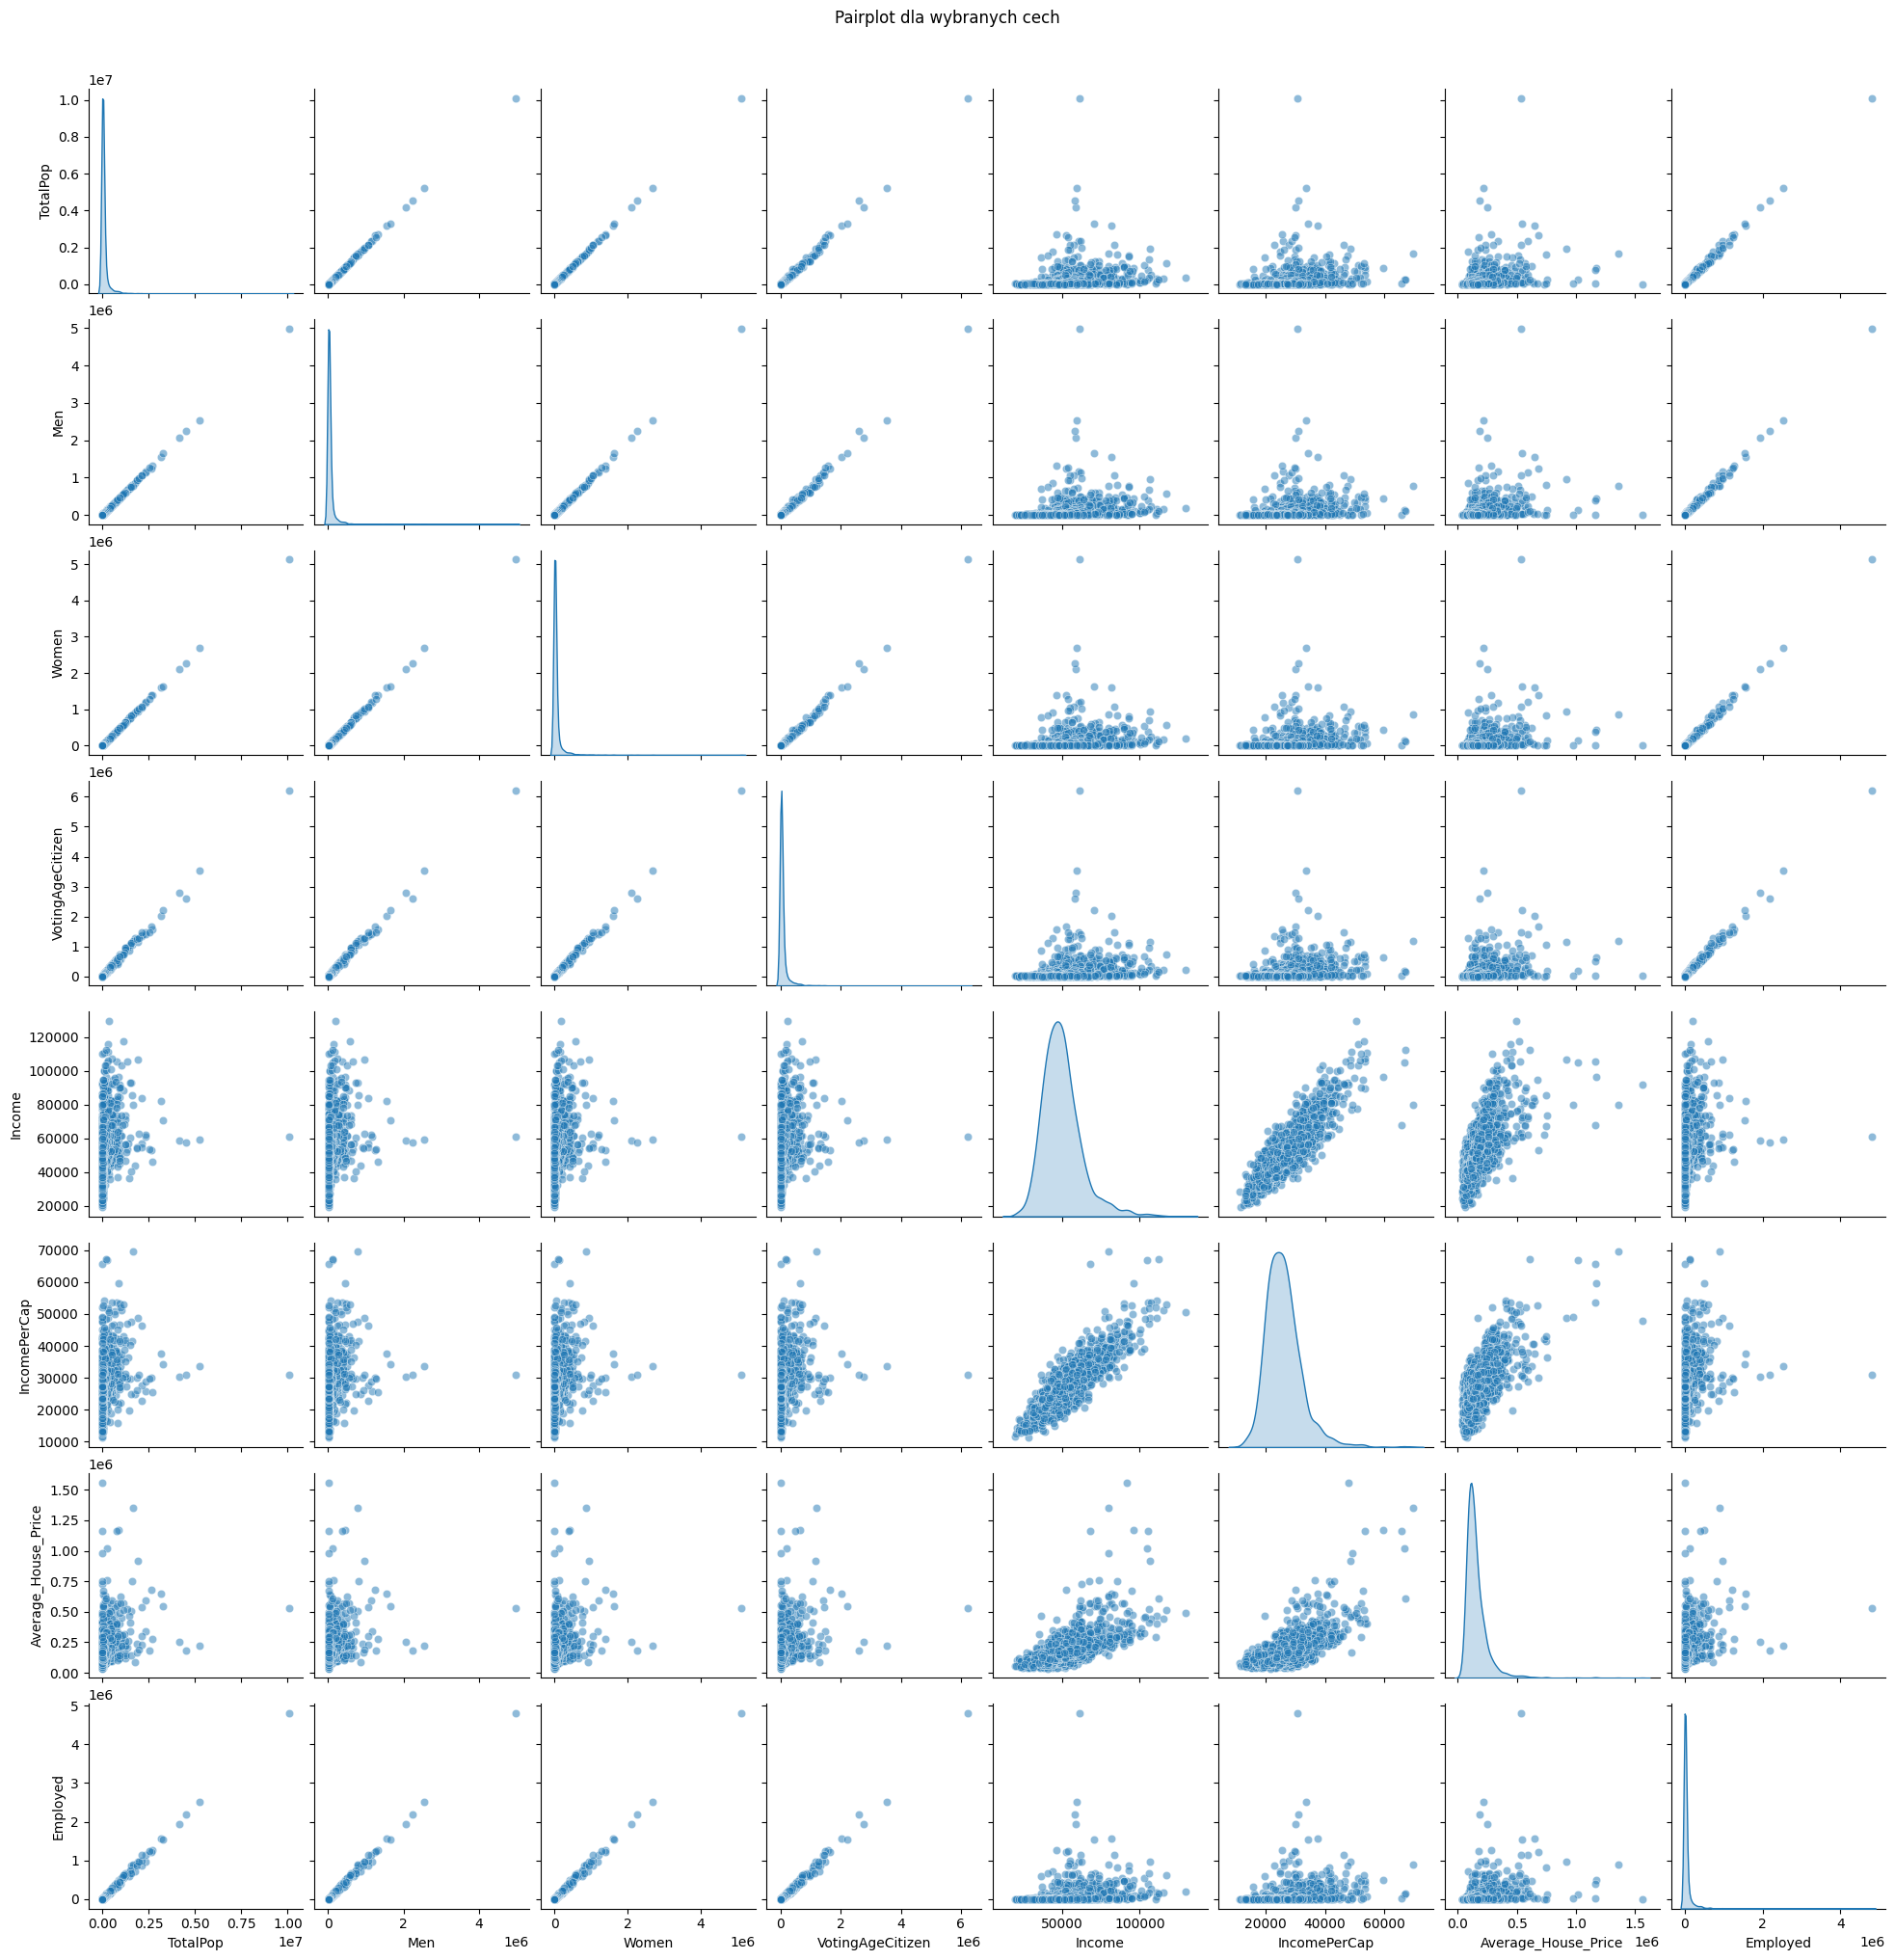

#### Statystyki

In [25]:
df_merged.describe()

,CountyId,TotalPop,Men,Women,Hispanic,White,Black,Native,Asian,Pacific,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,Average_House_Price
count,2894.000000,2.894000e+03,2.894000e+03,2.894000e+03,2894.000000,2894.000000,2894.000000,2894.000000,2894.000000,2894.000000,...,2894.000000,2894.000000,2894.000000,2.894000e+03,2894.000000,2894.000000,2894.000000,2894.000000,2894.000000,2.894000e+03
mean,30004.683483,1.071139e+05,5.274207e+04,5.437184e+04,8.830891,77.749309,8.741603,1.323048,1.304838,0.074084,...,1.525708,4.641983,23.583898,5.025315e+04,75.684278,16.474119,7.572806,0.269730,6.329682,1.562905e+05
std,14964.211718,3.397613e+05,1.668508e+05,1.729486e+05,13.065583,19.061987,13.991384,4.924516,2.623105,0.400275,...,1.122600,2.710060,5.457818,1.630850e+05,6.692088,5.510494,3.445079,0.404429,2.762177,1.012442e+05
min,1001.000000,4.530000e+02,2.350000e+02,2.180000e+02,0.000000,0.600000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,6.100000,2.560000e+02,34.300000,6.100000,0.700000,0.000000,0.000000,3.565224e+04
25%,18153.500000,1.265300e+04,6.390250e+03,6.204250e+03,2.100000,66.600000,0.600000,0.100000,0.300000,0.000000,...,0.900000,2.900000,19.800000,5.106250e+03,72.300000,12.600000,5.300000,0.100000,4.500000,1.001607e+05
50%,29090.000000,2.773800e+04,1.387250e+04,1.393200e+04,3.900000,84.700000,2.200000,0.300000,0.600000,0.000000,...,1.300000,4.100000,23.300000,1.166450e+04,76.600000,15.500000,6.700000,0.200000,6.100000,1.313707e+05
75%,42114.500000,7.091925e+04,3.528525e+04,3.573125e+04,9.200000,93.000000,9.875000,0.600000,1.200000,0.100000,...,1.900000,5.700000,26.900000,3.106600e+04,80.500000,19.075000,8.900000,0.300000,7.800000,1.808528e+05
max,56045.000000,1.010572e+07,4.979641e+06,5.126081e+06,99.200000,99.800000,86.400000,82.200000,41.800000,11.400000,...,13.800000,29.600000,44.200000,4.805817e+06,88.800000,62.300000,36.800000,8.000000,22.200000,1.560582e+06


In [35]:
correlation_matrix = df_merged.iloc[:,3:].corr()
correlation_matrix

,TotalPop,Men,Women,Hispanic,White,Black,Native,Asian,Pacific,VotingAgeCitizen,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,Average_House_Price
TotalPop,1.000000,0.999884,0.999892,0.219218,-0.266168,0.067565,-0.044972,0.489066,0.062627,0.996781,...,0.077288,0.006287,0.160325,0.997909,0.199270,-0.147674,-0.141658,-0.082001,0.033726,0.352745
Men,0.999884,1.000000,0.999551,0.220562,-0.265595,0.065094,-0.044742,0.490208,0.064296,0.996295,...,0.077770,0.006718,0.159343,0.997793,0.198108,-0.146494,-0.141313,-0.081789,0.032988,0.353075
Women,0.999892,0.999551,1.000000,0.217874,-0.266662,0.069934,-0.045184,0.487857,0.061003,0.997029,...,0.076807,0.005870,0.161237,0.997802,0.200347,-0.148779,-0.141960,-0.082188,0.034430,0.352349
Hispanic,0.219218,0.220562,0.217874,1.000000,-0.627785,-0.104153,-0.009692,0.170682,0.050821,0.206016,...,0.092636,-0.019405,-0.103448,0.209461,-0.061611,0.074900,0.002144,-0.020393,0.069632,0.172806
White,-0.266168,-0.265595,-0.266662,-0.627785,1.000000,-0.632196,-0.200310,-0.293393,-0.127674,-0.261641,...,-0.129200,0.206072,-0.063596,-0.257471,0.105320,-0.285740,0.240741,0.101463,-0.421651,-0.122846
Black,0.067565,0.065094,0.069934,-0.104153,-0.632196,1.000000,-0.094934,0.012581,-0.046971,0.072108,...,0.040570,-0.308884,0.214021,0.062671,0.009990,0.186577,-0.303961,-0.119132,0.460784,-0.117172
Native,-0.044972,-0.044742,-0.045184,-0.009692,-0.200310,-0.094934,1.000000,-0.035394,0.030314,-0.048167,...,0.026740,0.091156,-0.136607,-0.047281,-0.304813,0.352131,0.023202,0.050854,0.144692,-0.027135
Asian,0.489066,0.490208,0.487857,0.170682,-0.293393,0.012581,-0.035394,1.000000,0.444607,0.497895,...,0.164364,0.048216,0.102770,0.504126,0.124627,-0.048959,-0.153457,-0.092180,-0.032743,0.563295
Pacific,0.062627,0.064296,0.061003,0.050821,-0.127674,-0.046971,0.030314,0.444607,1.000000,0.064815,...,0.063839,0.032002,-0.028861,0.061526,-0.049288,0.056148,0.005690,-0.004057,-0.009165,0.180624
VotingAgeCitizen,0.996781,0.996295,0.997029,0.206016,-0.261641,0.072108,-0.048167,0.497895,0.064815,1.000000,...,0.078525,0.005929,0.163022,0.995634,0.214030,-0.156076,-0.156148,-0.088431,0.033768,0.362589


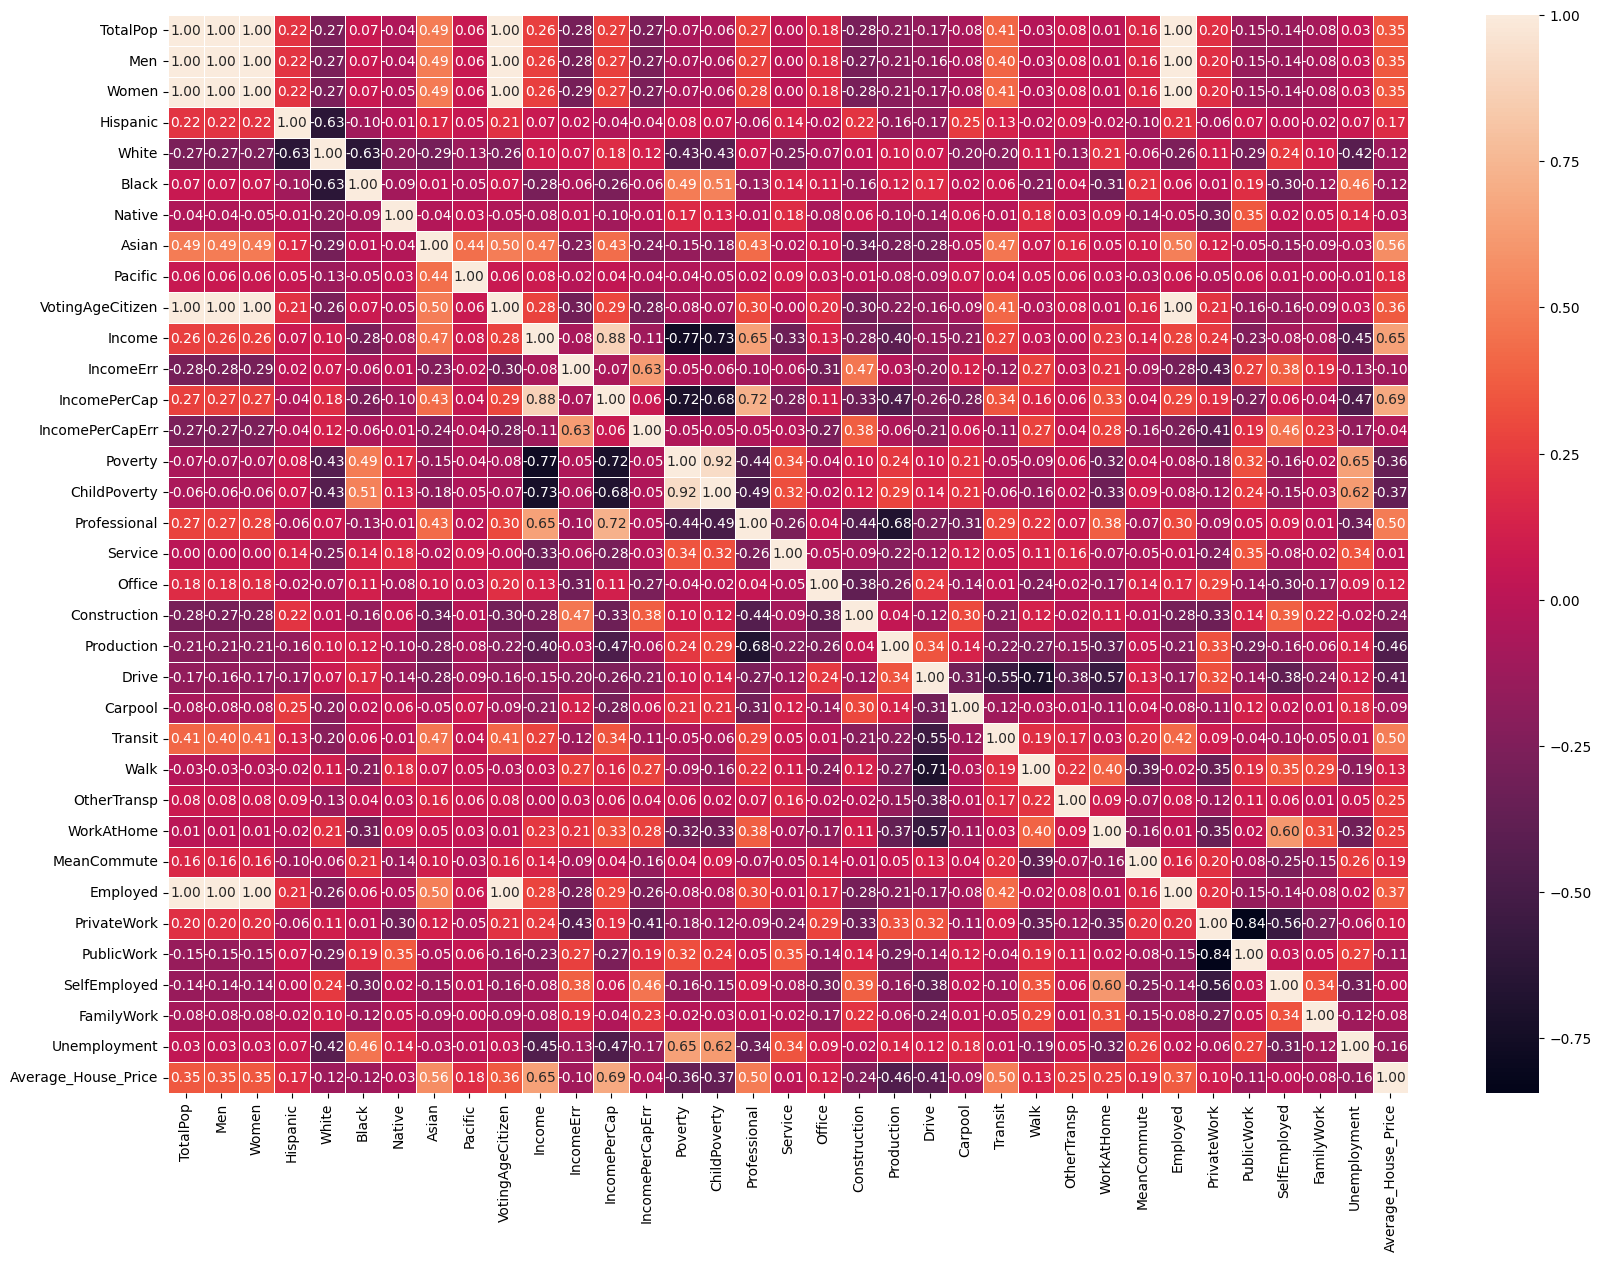

In [37]:
plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.5)

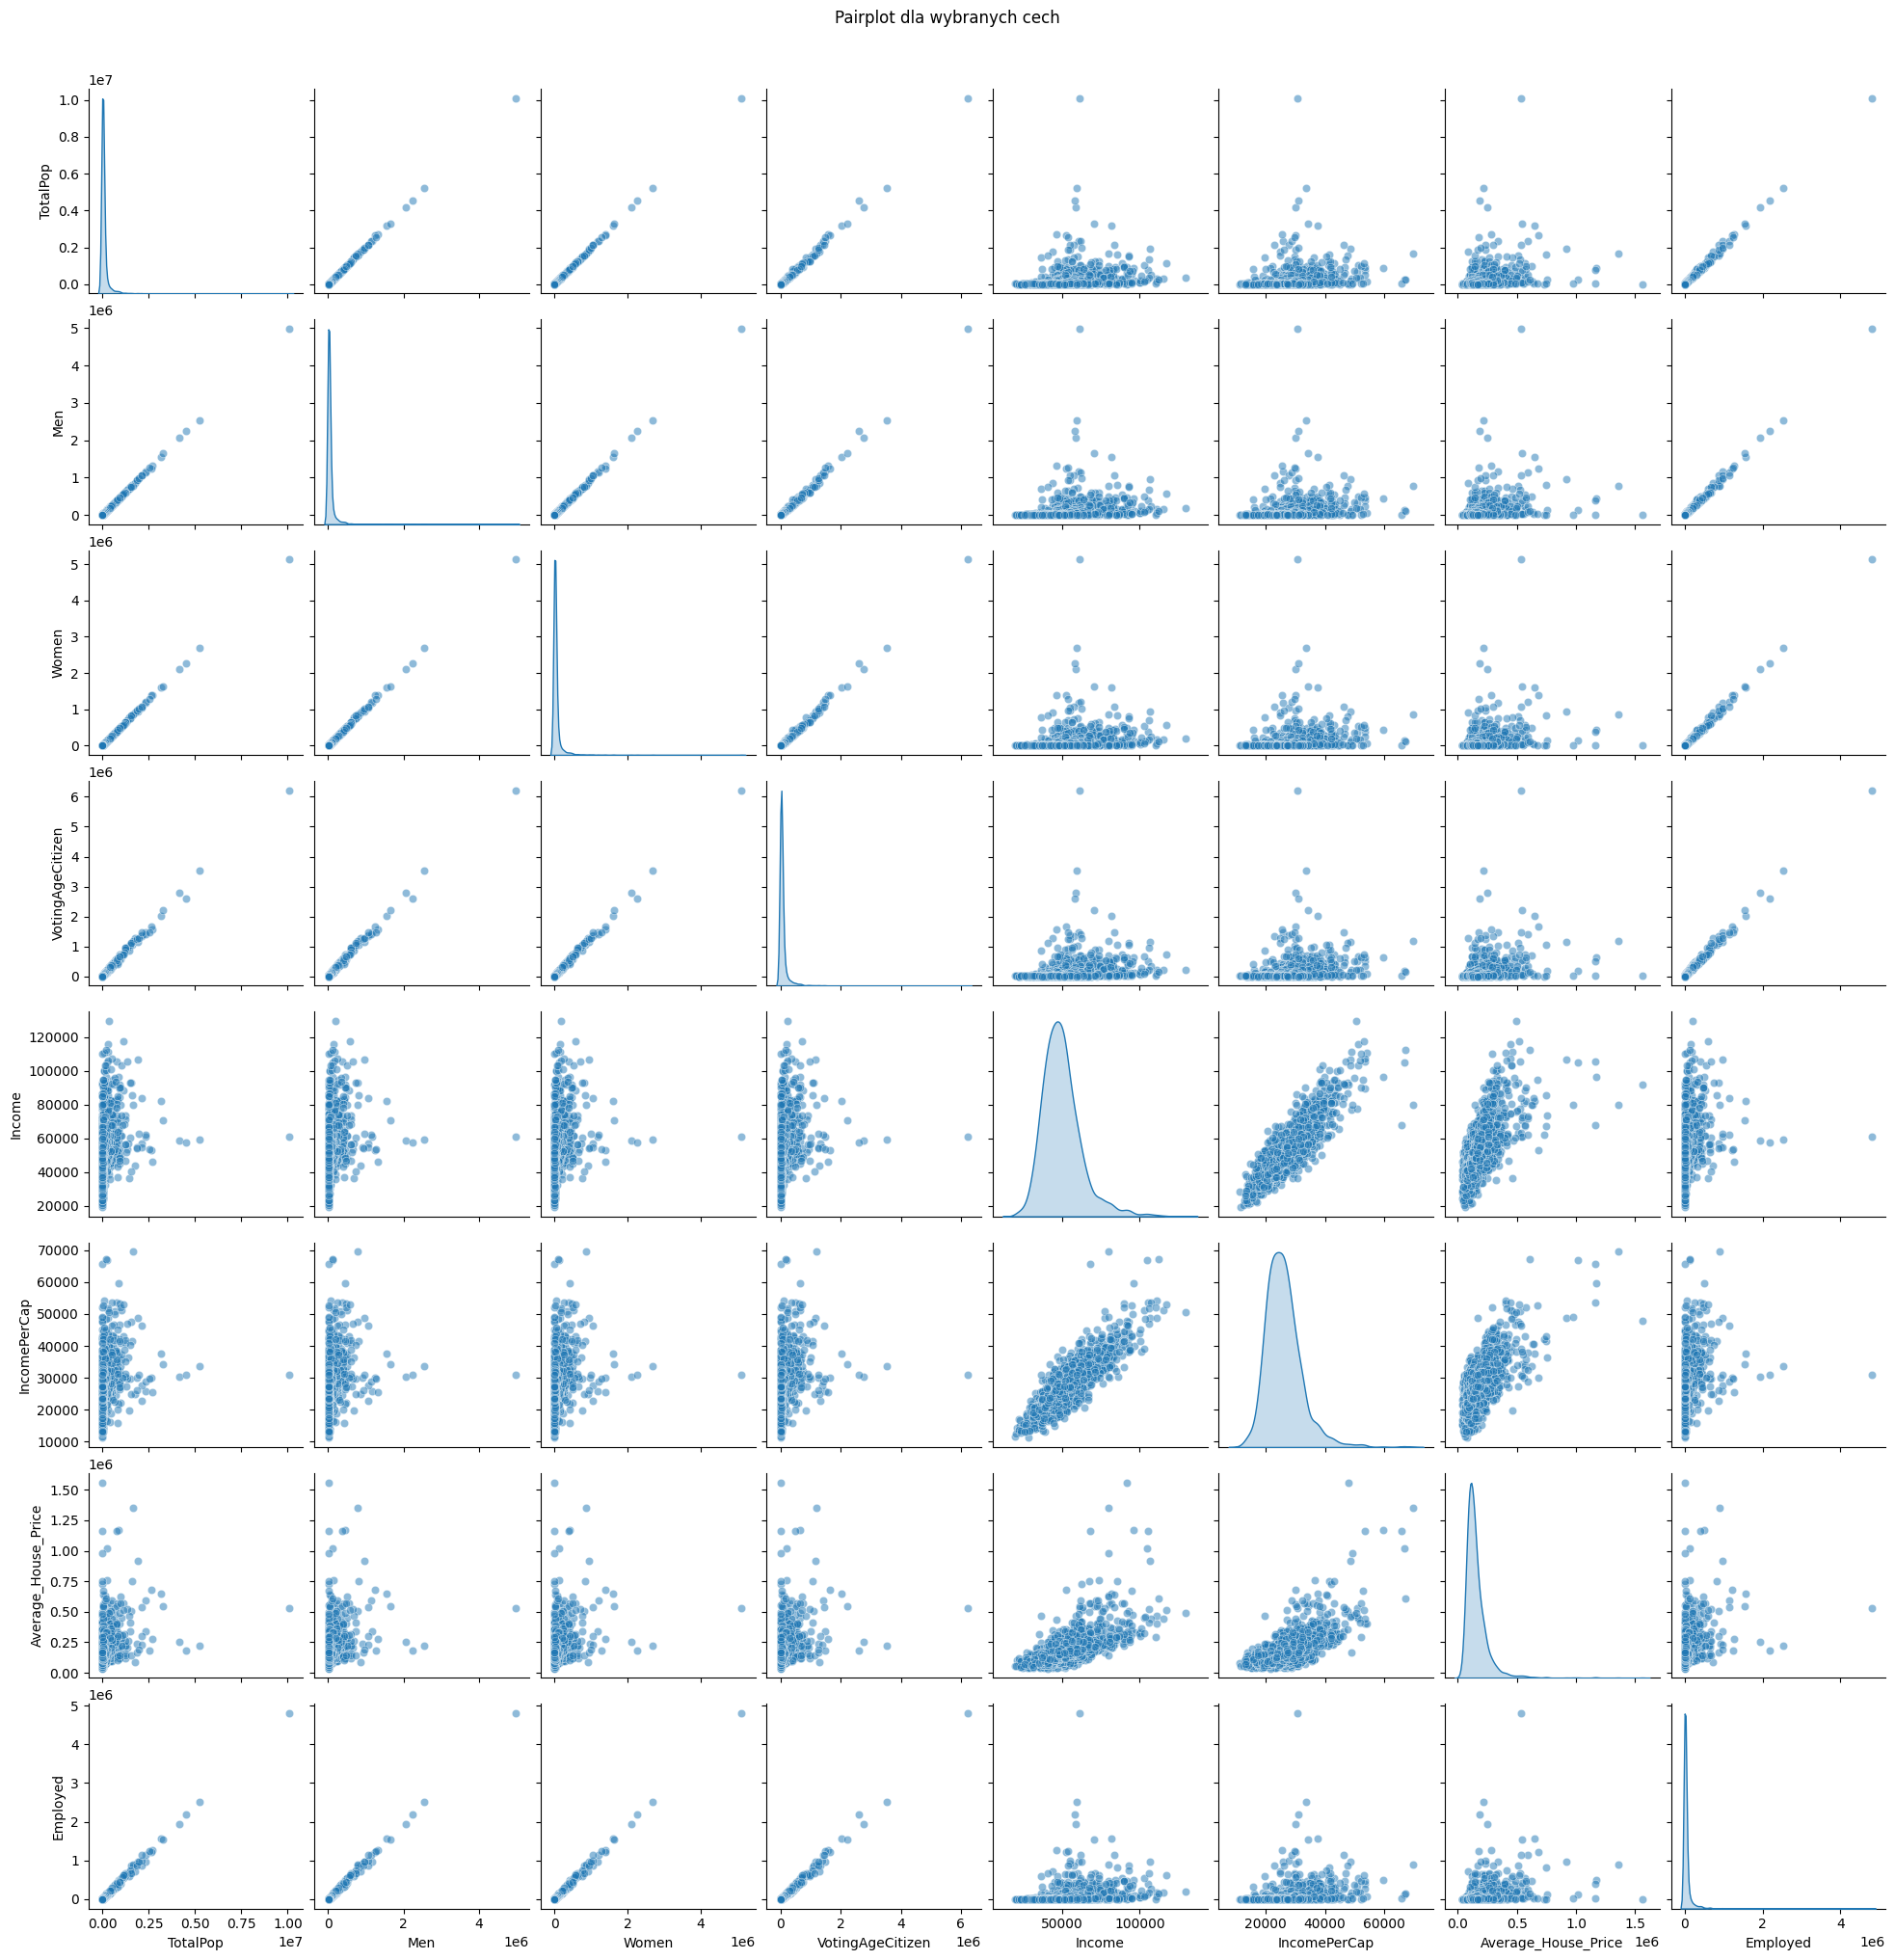

In [43]:
sns.pairplot(df_merged[non_percentage_columns], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot dla wybranych cech", y=1.02)
plt.show()